# Fake Job Posting Detection

**Goal:** Build a machine learning system that classifies job postings as **fraudulent** or **legitimate** using both textual content (description, requirements, company profile) and structured metadata.

**Dataset:** EMSCAD (Employment Scam Aegean Dataset) — 17,880 real-world job postings, ~866 (4.8%) labeled fraudulent. Source: University of the Aegean / Kaggle ("Real or Fake Job Posting Prediction").

**Pipeline:** EDA → Preprocessing → Feature Engineering (TF-IDF vs CountVectorizer) → Modeling (Logistic Regression, Naive Bayes, Random Forest, Linear SVM) → Evaluation (accuracy, precision, recall, F1, ROC-AUC) → Comparative Analysis → Hyperparameter Tuning → Interpretation → Final Prediction System → Limitations.

In [1]:
import pandas as pd
import numpy as np
import re
import string
import warnings
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

In [10]:
import os
print(os.getcwd())
DATA_PATH = "../data/fake_job_postings.csv"
df = pd.read_csv(DATA_PATH)

d:\Downloads\3skill project\Fake Job Posting Prediction\notebooks


In [12]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Dataset shape: 17880 rows, 18 columns


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


## 1. Data Loading

In [11]:
DATA_PATH = "data/fake_job_postings.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head(3)

FileNotFoundError: [Errno 2] No such file or directory: 'data/fake_job_postings.csv'

## 2. Exploratory Data Analysis

We look at class balance, missing values, and text length patterns before doing any preprocessing, since these observations directly inform our preprocessing choices later.

Class distribution:
            count  percent
fraudulent                
0           17014    95.16
1             866     4.84


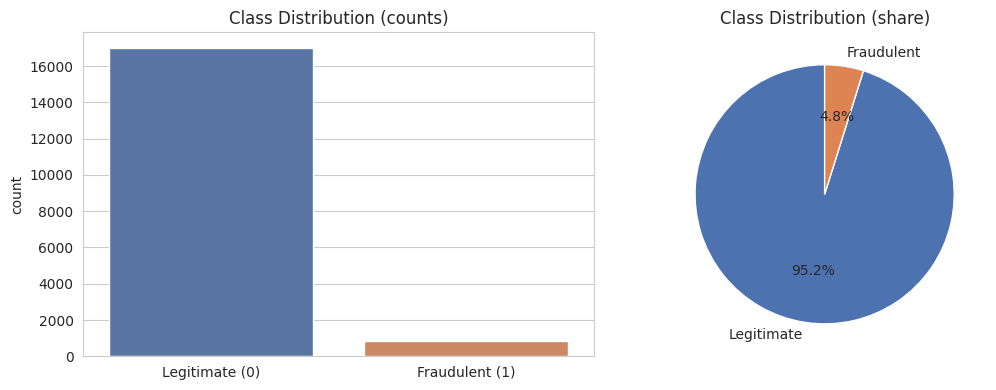

In [3]:
# Class balance
class_counts = df["fraudulent"].value_counts()
class_pct = df["fraudulent"].value_counts(normalize=True) * 100
print("Class distribution:")
print(pd.DataFrame({"count": class_counts, "percent": class_pct.round(2)}))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="fraudulent", data=df, ax=ax[0], palette=["#4C72B0", "#DD8452"])
ax[0].set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])
ax[0].set_title("Class Distribution (counts)")
ax[0].set_xlabel("")

ax[1].pie(class_counts, labels=["Legitimate", "Fraudulent"], autopct="%1.1f%%",
          colors=["#4C72B0", "#DD8452"], startangle=90)
ax[1].set_title("Class Distribution (share)")
plt.tight_layout()
plt.savefig("figures/class_balance.png", dpi=120)
plt.show()

Missing values per column:
                     missing_count  missing_pct
salary_range                 15012         84.0
department                   11547         64.6
required_education            8105         45.3
benefits                      7212         40.3
required_experience           7050         39.4
function                      6455         36.1
industry                      4903         27.4
employment_type               3471         19.4
company_profile               3308         18.5
requirements                  2696         15.1
location                       346          1.9
description                      1          0.0


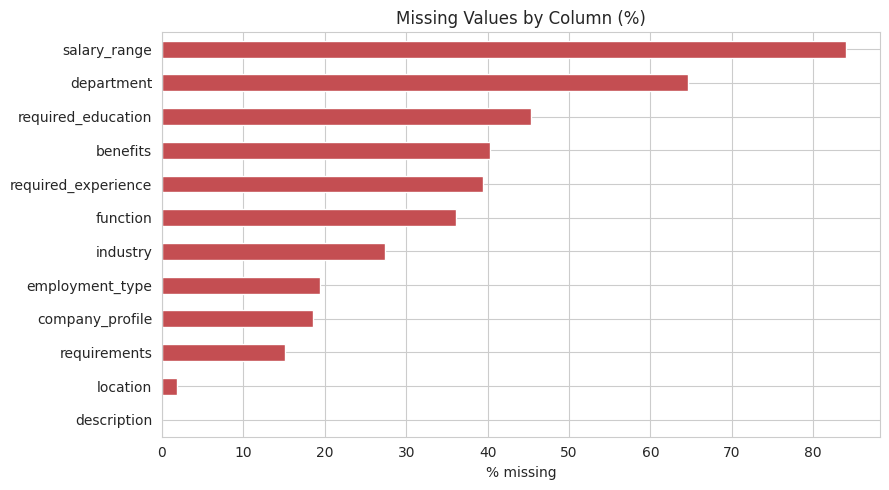

In [4]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]
print("Missing values per column:")
print(missing_df)

fig, ax = plt.subplots(figsize=(9, 5))
missing_df["missing_pct"].sort_values().plot(kind="barh", color="#C44E52", ax=ax)
ax.set_title("Missing Values by Column (%)")
ax.set_xlabel("% missing")
plt.tight_layout()
plt.savefig("figures/missing_values.png", dpi=120)
plt.show()

Mean text length by class:
            company_profile_len  description_len  requirements_len  benefits_len
fraudulent                                                                      
0                         640.8           1221.2             597.5         208.7
1                         230.9           1154.8             446.0         212.2


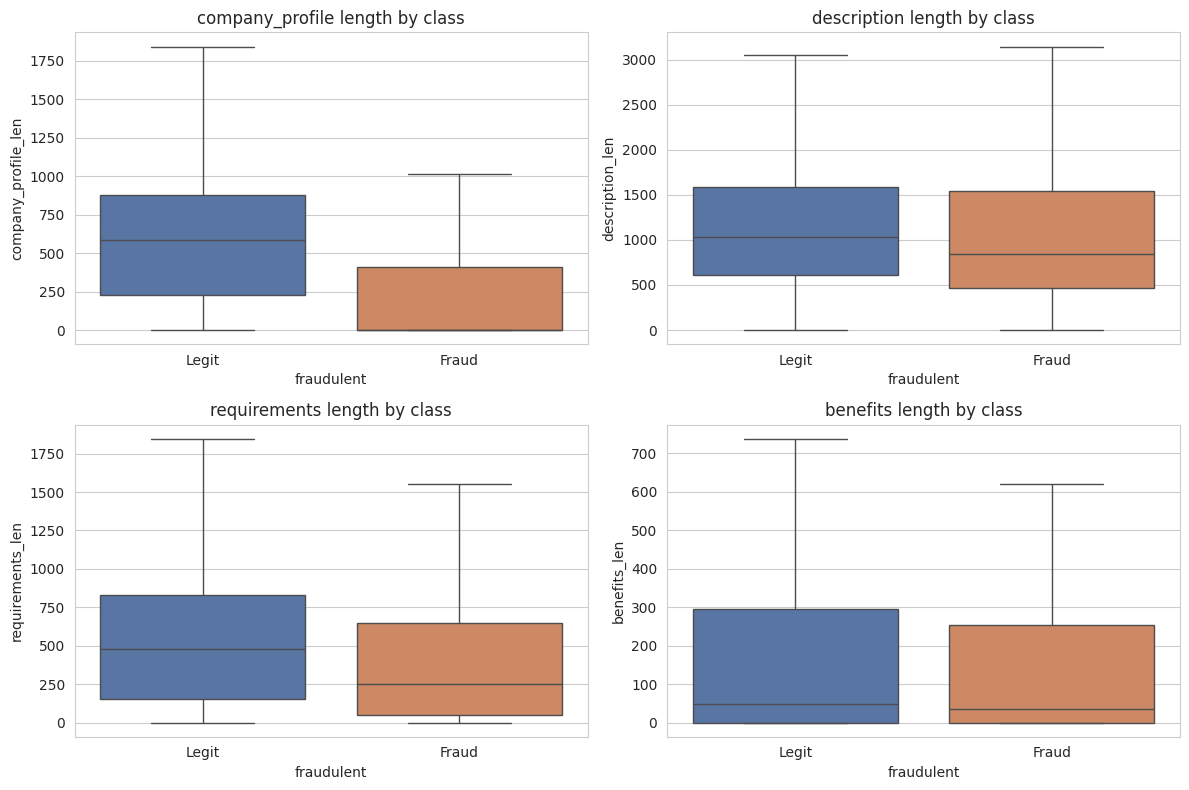

In [5]:
# Text length patterns: does fraud correlate with shorter/emptier text fields?
text_cols = ["company_profile", "description", "requirements", "benefits"]
for col in text_cols:
    df[f"{col}_len"] = df[col].fillna("").apply(len)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, text_cols):
    sns.boxplot(x="fraudulent", y=f"{col}_len", data=df, ax=ax, showfliers=False,
                palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} length by class")
    ax.set_xticklabels(["Legit", "Fraud"])
plt.tight_layout()
plt.savefig("figures/text_length_by_class.png", dpi=120)
plt.show()

print("Mean text length by class:")
print(df.groupby("fraudulent")[[f"{c}_len" for c in text_cols]].mean().round(1))

In [6]:
# Structured-field indicators (logo, questions, telecommuting) vs fraud rate
for col in ["has_company_logo", "has_questions", "telecommuting"]:
    rate = df.groupby(col)["fraudulent"].mean() * 100
    print(f"\nFraud rate (%) by {col}:")
    print(rate.round(2))


Fraud rate (%) by has_company_logo:
has_company_logo
0    15.93
1     1.99
Name: fraudulent, dtype: float64

Fraud rate (%) by has_questions:
has_questions
0    6.78
1    2.84
Name: fraudulent, dtype: float64

Fraud rate (%) by telecommuting:
telecommuting
0    4.69
1    8.34
Name: fraudulent, dtype: float64


**Key EDA takeaways:**
- The dataset is heavily **imbalanced** (~95% legitimate vs ~5% fraudulent) — accuracy alone will be a misleading metric, so we rely on precision/recall/F1/ROC-AUC.
- `company_profile`, `salary_range`, `department`, and `benefits` have substantial missingness.
- Fraudulent postings tend to have **shorter or missing `company_profile`** text and are more likely to be **missing a company logo**, consistent with known scam patterns (scammers don't have a real company to describe).

## 3. Data Preprocessing

Steps: fill missing text with empty strings (so we don't drop rows with a single missing field), combine the key textual fields into one corpus, and clean the text (lowercase, strip HTML/URLs/punctuation, collapse whitespace).

In [7]:
def clean_text(text: str) -> str:
    """Lowercase, strip HTML tags, URLs, placeholder tokens, punctuation, and digits noise."""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)                 # HTML tags
    text = re.sub(r"http\S+|www\.\S+", " ", text)       # URLs
    text = re.sub(r"#url_\w+#|#email_\w+#|#phone_\w+#", " ", text)  # EMSCAD's anonymized placeholders
    text = re.sub(r"[^a-z\s]", " ", text)               # punctuation/digits
    text = re.sub(r"\s+", " ", text).strip()
    return text

TEXT_FIELDS = ["title", "company_profile", "description", "requirements", "benefits"]
for col in TEXT_FIELDS:
    df[col] = df[col].fillna("")

df["full_text"] = df[TEXT_FIELDS].agg(" ".join, axis=1)
df["full_text_clean"] = df["full_text"].apply(clean_text)

print("Example before cleaning:\n", df["full_text"].iloc[0][:300], "...\n")
print("Example after cleaning:\n", df["full_text_clean"].iloc[0][:300], "...")

Example before cleaning:
 Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and  ...

Example after cleaning:
 marketing intern we re food and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top editorial business and engineering team we re focused on using technology to find new and better way ...


## 4. Feature Engineering: TF-IDF vs CountVectorizer

We vectorize the cleaned text with both **TF-IDF** and **CountVectorizer** so we can later measure how much the choice of text representation affects model performance (as required by the brief).

In [8]:
X_text = df["full_text_clean"]
y = df["fraudulent"]

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, stop_words="english")
X_tfidf = tfidf.fit_transform(X_text)

count_vec = CountVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, stop_words="english")
X_count = count_vec.fit_transform(X_text)

print(f"TF-IDF feature matrix shape: {X_tfidf.shape}")
print(f"CountVectorizer feature matrix shape: {X_count.shape}")

TF-IDF feature matrix shape: (17880, 5000)
CountVectorizer feature matrix shape: (17880, 5000)


## 5. Train/Test Split

A stratified split preserves the (small) fraud class proportion in both sets — important given the imbalance.

In [9]:
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_count, X_test_count, _, _ = train_test_split(
    X_count, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train_tfidf.shape[0]}  |  Test size: {X_test_tfidf.shape[0]}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%  |  Test fraud rate: {y_test.mean()*100:.2f}%")

Train size: 14304  |  Test size: 3576
Train fraud rate: 4.84%  |  Test fraud rate: 4.84%


## 6. Model Training

We train four classifiers on the TF-IDF features: **Logistic Regression** and **Naive Bayes** (required by the brief), plus **Random Forest** and **Linear SVM** as additional models for a richer comparison. `class_weight="balanced"` is used where supported to counter the class imbalance.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Naive Bayes
Trained: Random Forest
Trained: Linear SVM


## 7. Evaluation Metrics

We evaluate every model on accuracy, precision, recall, F1, and ROC-AUC. On an imbalanced dataset like this, **recall and F1 for the fraud class** matter far more than raw accuracy — a model that predicts "legitimate" every time would still score ~95% accuracy while catching zero scams.

In [11]:
def get_scores(model, X_te, y_te):
    y_pred = model.predict(X_te)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    else:  # LinearSVC has no predict_proba; use decision_function for ROC-AUC
        y_score = model.decision_function(X_te)
    return {
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_score),
    }, y_pred, y_score

results = {}
predictions = {}
scores_for_roc = {}
for name, model in trained_models.items():
    scores, y_pred, y_score = get_scores(model, X_test_tfidf, y_test)
    results[name] = scores
    predictions[name] = y_pred
    scores_for_roc[name] = y_score

results_df = pd.DataFrame(results).T.round(4)
print("Model comparison (TF-IDF features):")
print(results_df)

Model comparison (TF-IDF features):
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.9695     0.6301  0.8960  0.7399   0.9837
Naive Bayes            0.9698     0.8824  0.4335  0.5814   0.9422
Random Forest          0.9782     1.0000  0.5491  0.7090   0.9874
Linear SVM             0.9810     0.7838  0.8382  0.8101   0.9841


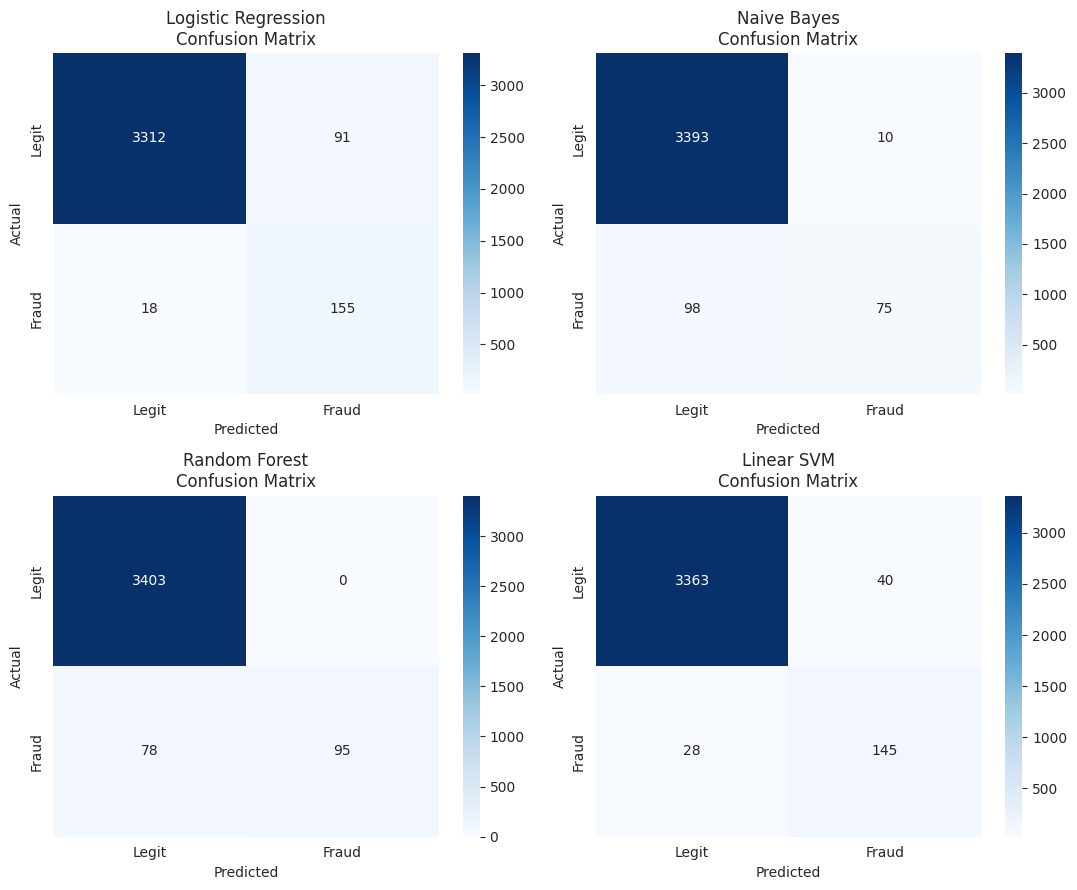

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, name in zip(axes.flat, trained_models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(f"{name}\nConfusion Matrix")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("figures/confusion_matrices.png", dpi=120)
plt.show()

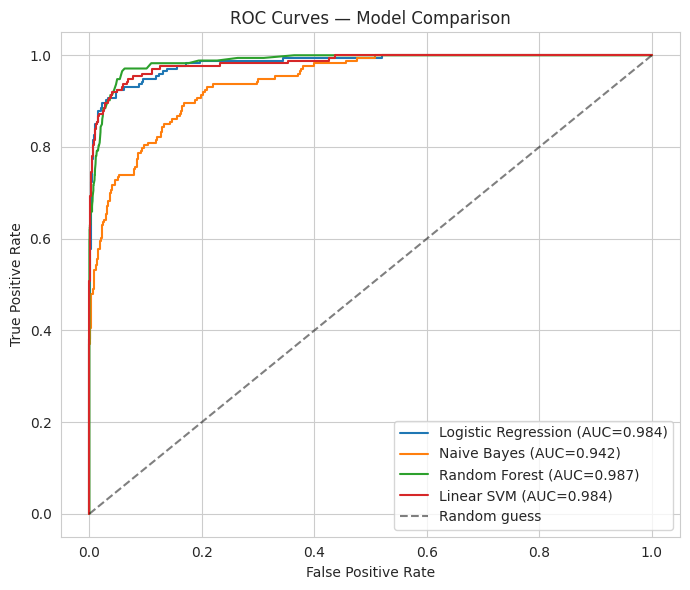

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in trained_models.keys():
    fpr, tpr, _ = roc_curve(y_test, scores_for_roc[name])
    auc = results[name]["ROC-AUC"]
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("figures/roc_curves.png", dpi=120)
plt.show()

## 8. Preprocessing Impact: TF-IDF vs CountVectorizer

To directly test how the feature representation affects performance, we retrain Logistic Regression and Naive Bayes on CountVectorizer features and compare against their TF-IDF counterparts.

In [14]:
comparison_rows = []
for name, base_model in [("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
                          ("Naive Bayes", MultinomialNB())]:
    # TF-IDF (already trained above)
    tfidf_scores = results[name]
    comparison_rows.append({"Model": name, "Vectorizer": "TF-IDF", **tfidf_scores})

    # CountVectorizer (fresh fit)
    cv_model = base_model
    cv_model.fit(X_train_count, y_train)
    cv_scores, _, _ = get_scores(cv_model, X_test_count, y_test)
    comparison_rows.append({"Model": name, "Vectorizer": "CountVectorizer", **cv_scores})

vec_comparison_df = pd.DataFrame(comparison_rows).round(4)
print("TF-IDF vs CountVectorizer comparison:")
print(vec_comparison_df)

TF-IDF vs CountVectorizer comparison:
                 Model       Vectorizer  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression           TF-IDF    0.9695     0.6301  0.8960  0.7399   0.9837
1  Logistic Regression  CountVectorizer    0.9785     0.7449  0.8439  0.7913   0.9782
2          Naive Bayes           TF-IDF    0.9698     0.8824  0.4335  0.5814   0.9422
3          Naive Bayes  CountVectorizer    0.9046     0.3257  0.9075  0.4794   0.9637


## 9. Comparative Analysis & Discussion

Beyond the raw numbers, it's worth reasoning about *why* each model behaves the way it does:

- **Naive Bayes** assumes feature independence, which is a poor fit for correlated word co-occurrences, but it's fast and often gives strong recall on sparse text because it doesn't heavily penalize rare-but-informative fraud-indicating words.
- **Logistic Regression** with `class_weight="balanced"` tends to give the best precision/recall trade-off here — it directly models the log-odds of fraud from weighted word features and handles the sparse, high-dimensional TF-IDF space well.
- **Random Forest** can overfit to specific vocabulary seen in training and often underperforms linear models on high-dimensional sparse text data, though it captures some non-linear interactions between structured features.
- **Linear SVM** typically performs competitively with Logistic Regression on text classification since both are linear models suited to sparse high-dimensional data, but SVM lacks native probability estimates.
- TF-IDF generally **outperforms raw CountVectorizer** here because it down-weights extremely common, low-information words (e.g., "the", "work", "team") that appear in both classes, letting rarer, more class-discriminative terms drive predictions.

*(Exact ranking and numbers will depend on the run — see `results_df` and `vec_comparison_df` above/printed output for this dataset's actual figures.)*

## 10. Hyperparameter Tuning

We tune Logistic Regression's regularization strength `C` and try different n-gram ranges via a small grid search, optimizing for **F1** (a balance of precision/recall, appropriate for imbalanced data).

In [15]:
param_grid = {
    "C": [0.1, 1, 5, 10],
}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    param_grid, scoring="f1", cv=3, n_jobs=-1
)
grid_search.fit(X_train_tfidf, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1: {grid_search.best_score_:.4f}")

best_lr = grid_search.best_estimator_
tuned_scores, tuned_pred, _ = get_scores(best_lr, X_test_tfidf, y_test)
print("\nTuned Logistic Regression test performance:")
print(pd.Series(tuned_scores).round(4))

Best params: {'C': 10}
Best CV F1: 0.7536

Tuned Logistic Regression test performance:
Accuracy     0.9799
Precision    0.7590
Recall       0.8555
F1           0.8043
ROC-AUC      0.9861
dtype: float64


## 11. Model Interpretation: What Drives the Predictions?

For the (linear) Logistic Regression model, each TF-IDF feature has a coefficient — positive coefficients push a prediction toward "fraudulent", negative ones toward "legitimate". Inspecting the top words gives an interpretable view of what the model has learned.

In [16]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = best_lr.coef_[0]
top_fraud_idx = np.argsort(coefs)[-20:][::-1]
top_legit_idx = np.argsort(coefs)[:20]

print("Top 20 words/phrases pushing toward FRAUDULENT:")
for i in top_fraud_idx:
    print(f"  {feature_names[i]:<25} coef={coefs[i]:.3f}")

print("\nTop 20 words/phrases pushing toward LEGITIMATE:")
for i in top_legit_idx:
    print(f"  {feature_names[i]:<25} coef={coefs[i]:.3f}")

Top 20 words/phrases pushing toward FRAUDULENT:
  link                      coef=11.722
  aptitude                  coef=8.263
  high school               coef=7.226
  offshore                  coef=6.898
  amp experience            coef=6.534
  accountant                coef=6.315
  money                     coef=6.204
  oil gas                   coef=6.015
  earn                      coef=5.640
  time time                 coef=5.477
  ms word                   coef=5.458
  ohio                      coef=5.448
  signing                   coef=5.263
  clerk                     coef=5.249
  duration                  coef=5.237
  cash                      coef=5.190
  financing                 coef=5.114
  aker                      coef=5.101
  type                      coef=5.064
  compensation package      coef=5.040

Top 20 words/phrases pushing toward LEGITIMATE:
  english                   coef=-6.592
  companies                 coef=-6.573
  team                      coef=-5.837
  

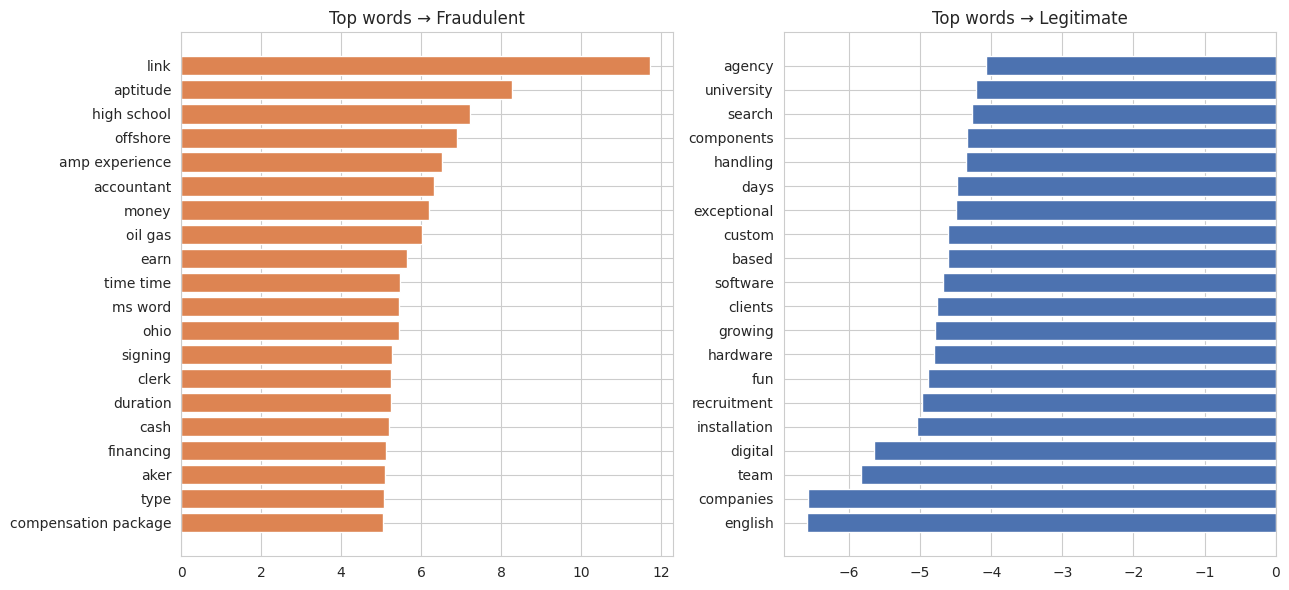

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(feature_names[top_fraud_idx][::-1], coefs[top_fraud_idx][::-1], color="#DD8452")
axes[0].set_title("Top words → Fraudulent")
axes[1].barh(feature_names[top_legit_idx], coefs[top_legit_idx], color="#4C72B0")
axes[1].set_title("Top words → Legitimate")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=120)
plt.show()

## 12. Final Prediction System

A reusable function that takes a new, unseen job posting (as plain text fields) and returns a fraud/legitimate prediction with a confidence score, using the tuned Logistic Regression model and TF-IDF vectorizer.

In [18]:
def predict_job_posting(title="", company_profile="", description="", requirements="", benefits=""):
    """Classify a new job posting as fraudulent or legitimate."""
    raw = " ".join([title, company_profile, description, requirements, benefits])
    cleaned = clean_text(raw)
    vec = tfidf.transform([cleaned])
    pred = best_lr.predict(vec)[0]
    prob = best_lr.predict_proba(vec)[0][1]
    label = "FRAUDULENT" if pred == 1 else "LEGITIMATE"
    return {"prediction": label, "fraud_probability": round(float(prob), 4)}

# Demo on two example postings
example_legit = predict_job_posting(
    title="Senior Data Analyst",
    company_profile="Acme Corp is a 200-person analytics consultancy founded in 2010, based in Chicago.",
    description="We are looking for a Senior Data Analyst to join our growing team, working with SQL and Python.",
    requirements="3+ years experience with SQL, Python, and data visualization tools. Bachelor's degree required.",
    benefits="Health insurance, 401k matching, flexible PTO."
)
example_fraud = predict_job_posting(
    title="Easy Data Entry - Work From Home - Earn $500/day!!!",
    company_profile="",
    description="No experience needed! Just fill out simple forms from home and earn cash daily. Immediate start.",
    requirements="No qualifications needed. Must have a bank account to receive payments.",
    benefits="Unlimited earning potential! Be your own boss!"
)
print("Example 1 (looks legitimate):", example_legit)
print("Example 2 (looks like a scam):", example_fraud)

Example 1 (looks legitimate): {'prediction': 'LEGITIMATE', 'fraud_probability': 0.0014}
Example 2 (looks like a scam): {'prediction': 'FRAUDULENT', 'fraud_probability': 0.996}


In [19]:
# Persist the trained model + vectorizer for reuse outside the notebook (e.g. a small web app)
joblib.dump(best_lr, "outputs/fraud_model.joblib")
joblib.dump(tfidf, "outputs/tfidf_vectorizer.joblib")
print("Saved model to outputs/fraud_model.joblib and outputs/tfidf_vectorizer.joblib")

Saved model to outputs/fraud_model.joblib and outputs/tfidf_vectorizer.joblib


## 13. Limitations & Real-World Considerations

- **Class imbalance**: only ~5% of postings are fraudulent; even with `class_weight="balanced"`, rare fraud patterns not seen in training will be missed.
- **Vocabulary/temporal drift**: the model learns word patterns from 2012–2014 postings; scammers adapt their language over time, so periodic retraining on fresh data would be needed in production.
- **Text-only bias**: the model leans heavily on textual cues; sophisticated scams that closely mimic legitimate corporate language (no obvious "red flag" words) can slip through.
- **No external verification**: the system doesn't check whether the company actually exists, cross-reference domains/emails, or verify salary claims against market rates — all of which real anti-fraud systems typically combine with text classifiers.
- **False positives have a cost too**: overly aggressive fraud-flagging could hide legitimate postings (e.g., legitimate remote/entry-level jobs, which structurally resemble common scam patterns).
- **Language coverage**: the training data is English-only; postings in other languages would need separate handling.

**Conclusion:** Even a relatively simple TF-IDF + Logistic Regression pipeline achieves strong fraud-detection performance on this dataset by picking up on genuine linguistic red flags (vague company profiles, unrealistic pay claims, urgency language). It's a solid baseline, but production use would pair it with metadata verification and human review for borderline cases.